<a href="https://colab.research.google.com/github/Ayush765-spec/Pytorch-computer-vision-/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Different models for computer vision:-
1. Torchvision
2. torchvision.datasets
3. torchvision.models-get pretrained computer vision mdoels
4. torchviison.transform- functions for manipulating your vision data (images) to be suitable for use with an ML model
5. torch.utils.data.Dataset- Base dataset clas for Pytorch
7. torch.utils.data. DataLoader- Creates a Python iterable over a dataset

In [ ]:
#import Pytorch
import torch
from torch import nn
#import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#import matplotlib
import matplotlib.pyplot as plt

Getting a dataset:-
To begin working on a computer vision problems we get a computer vision dataset
We are going with FashionMNIST
MNIST stands for Maodified Institute of Standards and Technology



In [ ]:
#setup training data
train_data=datasets.FashionMNIST(
    root="data",#where to download the data to
    train=True, #get training data
    download=True, #downlaod data if it doesnt exist on disk
    transform=ToTensor(), #images come as PIL format we want to turn them into Tensors
    target_transform=None # we can transform labels as wll

)
#setup testing data
test_data=datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),

)

Checking the first sample of the training data

In [ ]:
#seeing the first sample of the training data
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
#whats the shape of the image
image.shape

torch.Size([1, 28, 28])

The above shape actually means that the color_channel=1,height=28 and width=28
 A color channel is a singke component of a digital image that stores intensity information for a specific colour (like Red, Green , Blue) or property like transparency or Alpha

In [ ]:
#how many samples are there
len(train_data.data), len(train_data.targets),len(test_data.data),len(test_data.targets)

(60000, 60000, 10000, 10000)

So we got 60,000 training samples and 10,000 testing samples

In [ ]:
#see classes
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Since we are working with 10 different classes it means our problem is multi -class classification


Image shape:torch.Size([1, 28, 28])


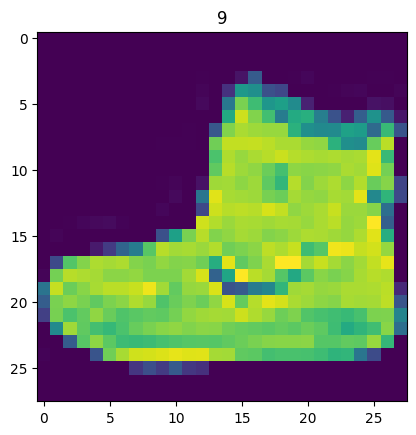

In [ ]:
#visualizing the data
import matplotlib.pyplot as plt
print (f"Image shape:{image.shape}")
plt.imshow(image.squeeze()) # image shape is [1,28,28]
plt.title(label);

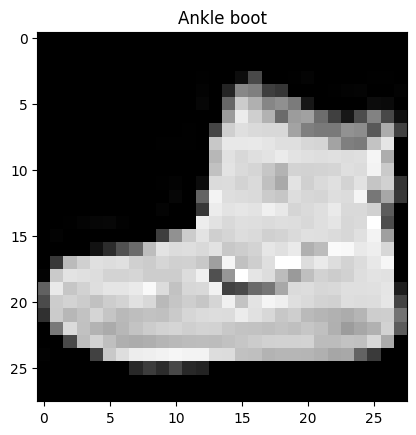

In [ ]:
#turning image into grayscale
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_names[label]);

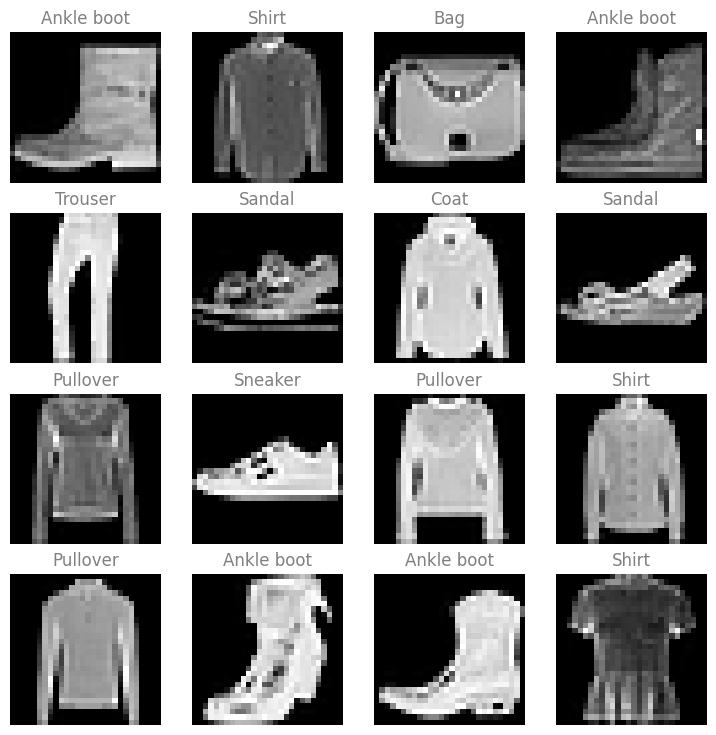

In [ ]:
#viweing few more images
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap='gray')
  plt.title(class_names[label],color='gray')
  plt.axis(False)

We have got the dataset the next step is to use DataLoader.
The DataLoader loads the data into a model for training and inference it turns a large dataset into a Python iterable of smaller chunks
These smaller chunks are called batches or mini-batches and can be set by the batch_size parameter

In an ideal world we would do the forward pass and the backward pass at once but once we start using really large datsets, unless we got infinte computing power its easier to break them into batches

It also gives our model more oppurtunities to improve

With mini-batches (smaller portions of the data) , gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch)

32 is a good batch size to start


In [ ]:
#creating Dataloader
from torch.utils.data import DataLoader
BATCH_SIZE=32

#turn datasets into iterable (batches)
train_dataloader=DataLoader(train_data, batch_size=BATCH_SIZE,shuffle=True)
test_dataloader=DataLoader(test_data,
                           batch_size=BATCH_SIZE,
                           shuffle=False)
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x79a035d8db20>, <torch.utils.data.dataloader.DataLoader object at 0x79a04505bbf0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [ ]:
#checking what is inside the training dataloader
train_features_batch, train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


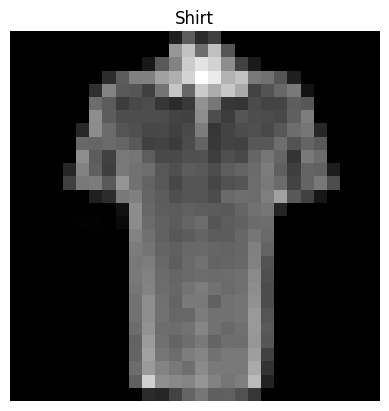

In [ ]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

Now we have loaded up the data and now we will build tha baseline model
MODEL_0 ---
our baseline model will have two nn.Linear() layers We will be using a differnent layer to start things And that is the nn.Flatten() layer nn.Flatten() compresses the dimensions of a tensor into a single vector


In [ ]:
#create a flatten layer
flatten_model=nn.Flatten()
#get a single sample
x=train_features_batch[0]
#flatten the sample
output=flatten_model(x)
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

#print(x)
#print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


The nn.Flatten layer took our shape from [color_channels,height,width] to [color_channels,height*width]

Creating our first model using nn.Flatten() as the first layer


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)

    )
  def forward(self,x):
    return self.layer_stack(x)

We have got a baseline model now we will instantiate a model

We need the following parameters:
1. input_size=784- this is hwo many features we have got going into the model its one for every pixel in the target image
2. hidden_units=10-- the number of units/neurons in the hidden layer(s) this number could be whatever we want to kewep the model small we will start with 10
3. ouput_shape=len(class_names)-- since we are working with a multi class classification proble, we need an output neuron per class in our dataset


In [ ]:
torch.manual_seed(42)
model_0= FashionMNISTModelV0(input_shape=784,
                             hidden_units=10,
                             output_shape=len(class_names))
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
import requests
from pathlib import Path
##download helper functions
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping downlaod")
else:
  print("Downloding helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping downlaod


In [ ]:
#import accuracy metric
from helper_functions import accuracy_fn
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

we will make a timijg function to test the timing of our model to train on cpu vs gpu



In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

steps to create training and testing data
1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss per batch
3. Loop theough testing batches, perform testing steps, calculate the test loss per batch
4. Print out whats happening
5. time it all out


In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 30.751 seconds


We are going to create a function that takes in a trained model, a DataLoadeer , a loss function and an accuracy function.

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

Setting up device agnositic code

Model training time is dependent on hardware used. Generally more processors means faster training and smaller models on smaller datasets will often train faster than large models and large datasets.


In [ ]:
import torch
device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Building model with non-linearity seeting the data we have been working with we nneed non linear and linear layers


In [ ]:
import torch
from torch import nn

#create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
  def __init__(self,input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )
  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

we will need input_shape=784(equal to the number of features of our image data) hidden_units=10(starting small and the same as our baseline model) and output_shape=len(class_name)

In [ ]:
torch.manual_seed(42)
model_1=FashionMNISTModelV1(input_shape=784,
                            hidden_units=10,
                            output_shape=len(class_names))
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

Now we will setup a loss function, an optimizer and an evaluation metric

In [ ]:
from helper_functions import accuracy_fn
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),
                          lr=0.1)

we have been writing training and testing loops again and again but now we will functionise them so that they can be called again and again and because we are using device agnoistic code now we will call .to(device) on out feature (X) and target(y) tensors.

for the training loop we will create a function called train_step( which takes in a model a DataLoader a loss fucntion and an evaluation function

In [ ]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device):
  train_loss,train_acc=0,0
  model.to(device)
  for batch,(X,y) in enumerate(data_loader):
    X,y=X.to(device), y.to(device)
    y_pred=model(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    train_acc+=accuracy_fn(y_true=y,
                           y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
def test_step(data_loader:torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device=device):
  test_loss,test_acc=0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y=X.to(device),y.to(device)
      test_pred=model(X)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y_true=y,
                            y_pred=test_pred.argmax(dim=1))
    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
  print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [ ]:
torch.manual_seed(42)

# Note: This will error due to `eval_model()` not using device agnostic code
model_1_results = eval_model(model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn)
model_1_results

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

In [ ]:
model_0_results

the results we have obtained is worse than before thus our model is overfitting on a small dataset hence we need to make another model or increase the size of our dataset


We will try making a cnn

We will leverage the nn.Conv2d() and nn.MaxPool2d() layers from torch.nn

In [ ]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

1. nn.Conv2d()-- also known as convolutional layer
2. nn.MaxPool2d()--also known as a max pooling layer

What does 2d stand for?
the 2d is for 2-dimensional data. As in our images have two dimensions height and width yes theres colour channel dimension but each of the colour channel dimensions have two dimensions too:height and width


In [ ]:
torch.manual_seed(42)
images=torch.randn(size=(32,3,64,64))
test_image=images[0]
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

We will create an example of nn.Conv2d() with various parameter:
in_channels(int)-- NUmber of channels in the input image
out_channels(int)--Number of channels produced by the convolution
kernel_size(int or tuple)== size of the convolving kernerl/filter
stride(int or tuple , optional)-- How big of a step the convolving kernel takes at a time
padding(int,tuple,str)--- Padding added to all four sides of input


Below is the example of what happens when we change the hyperparameters of a nn.Conv2d() layer


In [ ]:
torch.manual_seed(42)
conv_layer=nn.Conv2d(in_channels=3,
                     out_channels=10,
                     kernel_size=3,
                     stride=1,
                     padding=0)

conv_layer(test_image)

In [ ]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

In [ ]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

In [ ]:
torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

 our nn.Conv2d() is compressing the information stored in the image
 It does this by performing operations on the input(our test image) against its internal parameters.The goal of this is similar to all of the other neural networks we have been buildng
 Data goes in and the layers try to update their internal parameters(patterns) to lower the loss function thanks to some help from the optimizer.
 The only difference is how the differnet layers calculate their parameter updates or in Pytorch terms , the operation present in the layer forward() mathod.

In [ ]:
#check out the conv_layer_2 internal parameters
print (conv_layer_2.state_dict())

In [ ]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

What should we set the parameters of our nn.Conv2d() layers?

The best way to find out is to try out different values and see how they effect your model's performance

or even better find a working example on a problem similar to ours


The strategy is the same we start with random nos and go on improving our models performance


In [ ]:
# Print out original image shape without and with unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

A max pooling layer is a downsampling operation in a connvolutional neural networks (CNNS) that reduces the spatial dimensions(width and height) of input feature maps. It works by sliding window across the input and selecting the maximum pixel value from each region, retaining the most prominent features while discarding less crucial information

In [ ]:
torch.manual_seed(42)
#create a random tensor with a similar number of dimensions to our images
random_tensor=torch.randn(size=(1,1,2,2))
print(f"Random tensor:\n{random_tensor}\n")
print(f"Random tensor shape: {random_tensor.shape}\n")

#create a max pool layer
max_pool_layer=nn.MaxPool2d(kernel_size=2)
max_pool_tensor=max_pool_layer(random_tensor)
print(f"Random tensor:\n{max_pool_tensor}")
print(f"Max pool tensor shape:{max_pool_tensor.shape}")

we see that we have final two dimensions between random_tensor and max_pool_tensor where they go from [2,2] to [1,1]
in essence they get halved
and the change would be differnet for different values of kernel_size for nn.MaxPool2d()
we also notice the value leftover in max_pool_tensoris the maximum value from the random_tensor

**Essentially every layer in a neural network is trying top compress data from higherr dimensional space to lower dimensional space **


In [ ]:
import torch
from torch import nn

# Create a convolutional neural network (Included here to make this cell self-contained)
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

# Instantiate model_2 (Included here to make this cell self-contained)
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)

#setup loss and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [ ]:
#training and testing model_2 using our training and test functions
torch.manual_seed(42)
#measure time
from timeit import default_timer as timer
train_time_start_model_2=timer()

#train and test model
epochs=3
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n-------")
  train_step(data_loader=train_dataloader,
             model=model_2,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
  train_time_end_model_2=timer()
  total_train_time_model_2=print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)

In [ ]:
#get model_2 results
model_2_results=eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_2_results

In [ ]:
# Redefining eval_model to ensure the correct, device-agnostic version is in memory
import torch

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [ ]:
import pandas as pd

# Calculate model 1 results (assuming eval_model, model_1, test_dataloader, loss_fn, accuracy_fn, device are defined)
model_1_results = eval_model(model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

compare_results=pd.DataFrame([model_0_results,model_1_results,model_2_results])
compare_results

In [ ]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

In [ ]:
#making and doing predictions with our best model
def make_predictions(model:torch.nn.Module,data:list,device:torch.device):
  model.to(device)
  model.eval()
  all_pred_probs = [] # Initialize an empty list to store prediction probabilities
  with torch.inference_mode():
    for sample in data:
      #prepare sample
      sample=torch.unsqueeze(sample,dim=0).to(device)
      #forward pass(model outputs raw logit)
      pred_logit=model(sample)
      pred_probs=torch.softmax(pred_logit.squeeze(),dim=0)
      all_pred_probs.append(pred_probs.cpu()) # Append to the list
  return torch.stack(all_pred_probs) # Stack the list of tensors

In [ ]:
import random
random.seed(42)
test_samples=[]
test_labels=[]
for sample, label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

In [ ]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples,
                             device=device)

# View first two prediction probabilities list
pred_probs[:2]

now we can go from prediction probabilities to prediction labels by taking the torch.argmax() of the output of the torch.softmax() activation function


In [ ]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

In [ ]:
test_labels, pred_classes

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

There are many different evaluation matrices we can use for the classification of our problems

One of the most visual is the confusion matrix
A confusion matrix shows us where our classification model got confuses between predictions and true labels

The following are the steps we go theough to create a confusion matrix:
1. Make predictions with our trained model, model_2 (a confusion matrix compares predictions to true labels)
2. Make a confusin matrix using torchmetrics.ConfusionMatrix.
3. PLottinf the confusion matrix using
mlxtend.plotting.plt_confusion_matrix()

In [ ]:
from tqdm import tqdm
y_preds=[]
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader, desc="Making predictions"):

    X,y=X.to(device), y.to(device)
    y_logit=model_2(X)
    y_pred=torch.softmax(y_logit,dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor=torch.cat(y_preds)

In [ ]:
# Install numpy<2.0 first to ensure mlxtend compatibility
!pip install "numpy<2.0"
# Install torchmetrics and mlxtend
!pip install -q torchmetrics -U mlxtend

# Import after installation
import torchmetrics, mlxtend
import numpy as np # Import numpy to confirm its version
print(f"Numpy version: {np.__version__}")
print(f"mlxtend version: {mlxtend.__version__}")
print(f"torchmetrics version: {torchmetrics.__version__}")

In [ ]:
!pip install "numpy<2.0"

In [ ]:
import numpy as np
import pandas as pd

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

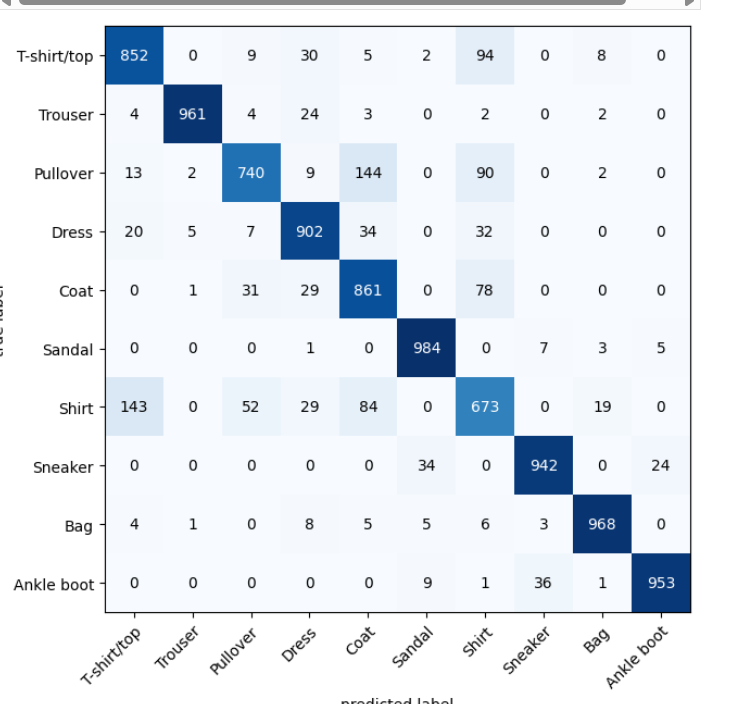

We can see our model does fairly well since most of the dark squares are down the diagonal from top left to bottom right (and ideal model will have only values in these squares and 0 everywhere else).

The model gets most "confused" on classes that are similar, for example predicting "Pullover" for images that are actually labelled "Shirt".

And the same for predicting "Shirt" for classes that are actually labelled "T-shirt/top".

This kind of information is often more helpful than a single accuracy metric because it tells use where a model is getting things wrong.

It also hints at why the model may be getting certain things wrong.

It's understandable the model sometimes predicts "Shirt" for images labelled "T-shirt/top".

We can use this kind of information to further inspect our models and data to see how it could be improved.